<a href="https://colab.research.google.com/github/kavy-sys/spccweb/blob/master/predection_of_house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training data is 79.8% of thr total data.
remaining testing data is20.2%
training data rsqaured is 0.75
Index(['Unnamed: 0', 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
       'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'],
      dtype='object')
the price premium for having an extra room is $3136.2
50     -1.59
367    10.84
34     -0.48
78      0.14
172    -0.28
       ...  
320    -0.70
15     -0.35
484     1.49
125    -0.94
265    -5.60
Name: PRICE, Length: 404, dtype: float64


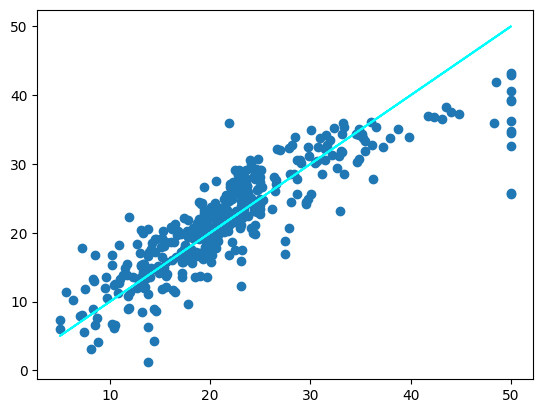

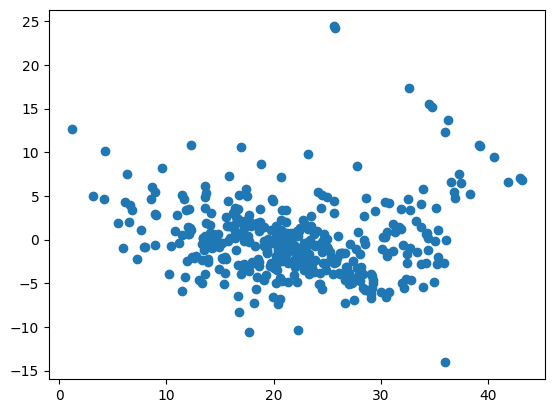

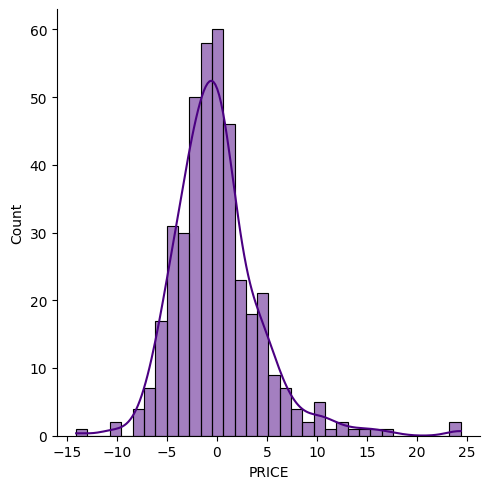

1.1080984082549072


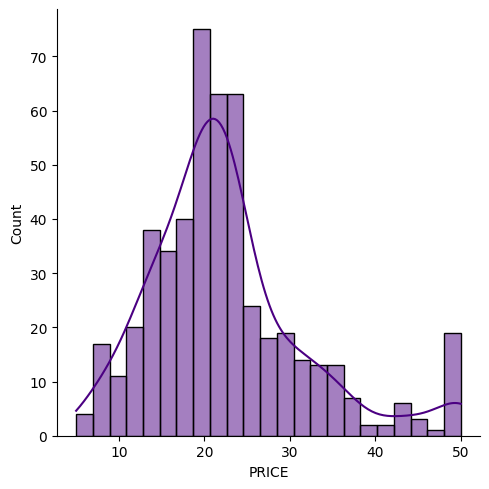

-0.33032129530987864


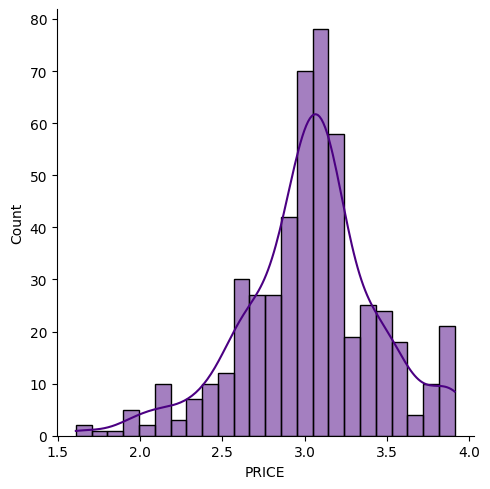

-0.33032129530987864


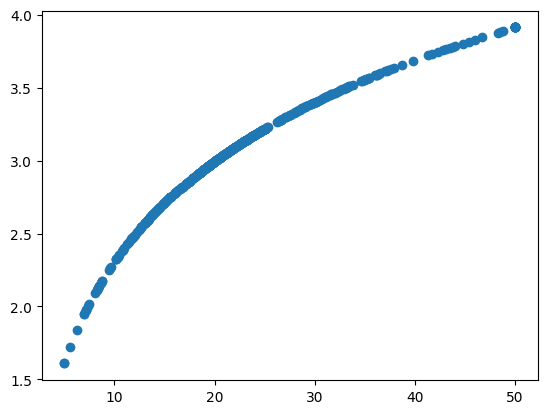

50     -1.59
367    10.84
34     -0.48
78      0.14
172    -0.28
       ...  
320    -0.70
15     -0.35
484     1.49
125    -0.94
265    -5.60
Name: PRICE, Length: 404, dtype: float64


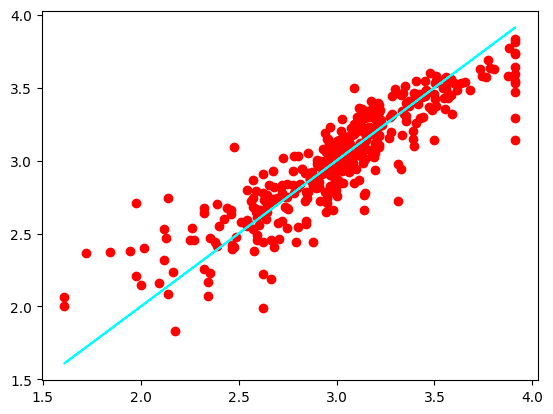

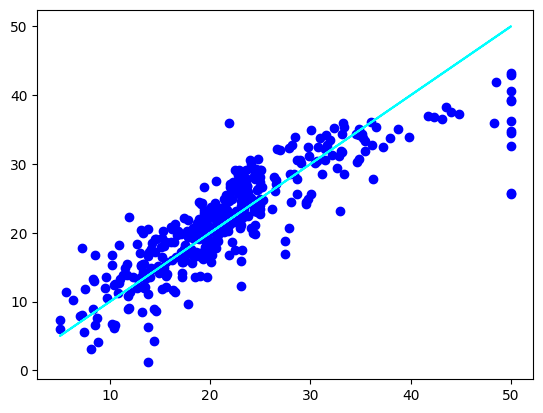

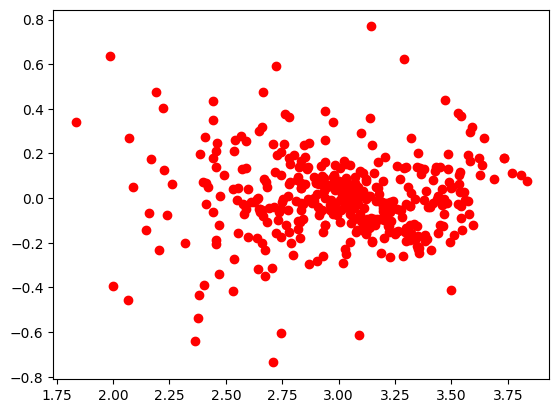

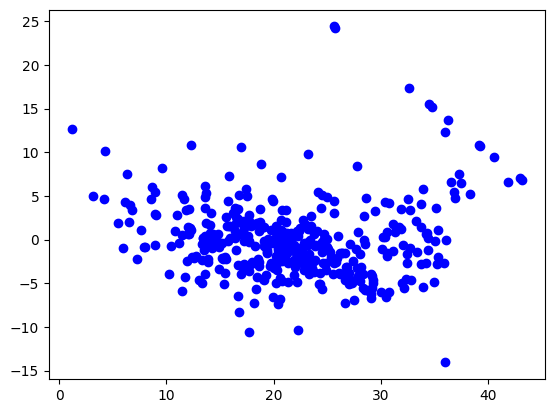

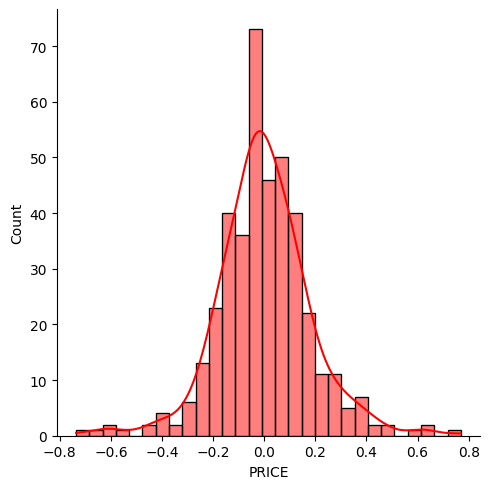

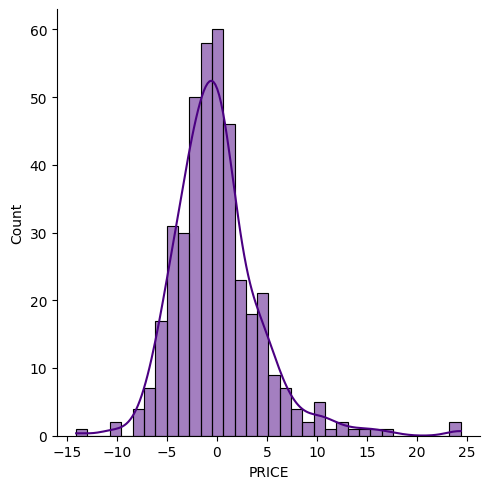

Original Model Test Data r-squared: 0.67
Log Model Test Data r-squared: 0.75
   Unnamed: 0  CRIM     ZN  INDUS  CHAS   NOX    RM    AGE  DIS   RAD     TAX  \
0       252.5  3.61  11.36  11.14  0.07  0.55  6.28  68.57  3.8  9.55  408.24   

   PTRATIO       B  LSTAT  
0    18.46  356.67  12.65  
$3.03
$20696.87
$2.95
$19158.32


In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df=pd.read_csv("boston.csv")
df.shape
df.isna().values.any()
df.duplicated().values.any()

#######home prices#######################
# sns.displot(df["PRICE"],kde=True,aspect=2,bins=50)
# plt.show()
########distance to employment - length of community########
# sns.displot(df["DIS"],kde=True,bins=50,aspect=2)
# plt.show()
##########number of rooms###########
# sns.displot(df["RM"],aspect=2,
#            kde=True,)
# plt.show()
####### the index of aacebility to highways############
# sns.displot(df["RAD"],kde=True,aspect=2,bins=50)
# plt.show()
####################next to rever##########33
# sns.displot(df["CHAS"])
# plt.show()


##########pair plot to see alll relations##############33

# sns.pairplot(df,kind="reg",plot_kws={'line_kws':{'color': 'cyan'}})
# plt.show()




###############comparision plots######################

###distance from employment (DIS) vs nitroxide pollution(NOX)###
# with sns.axes_style('darkgrid'):
#   sns.jointplot(x=df['DIS'],
#                 y=df['NOX'],
#                 height=8,
#                 kind='scatter',
#                 color='deeppink',
#                 joint_kws={'alpha':0.5})

# plt.show()



###factories(INDUS) vs nitrous oxide(NOX)###
# with sns.axes_style('darkgrid'):
#   sns.jointplot(x=df.NOX,
#                 y=df.INDUS,
#                 # kind='hex',
#                 height=7,
#                 color='darkgreen',
#                 joint_kws={'alpha':0.5})
# plt.show()


###lower income popullation(LSTAT) vs number of rooms(RM)###
# with sns.axes_style('darkgrid'):
#   sns.jointplot(x=df['LSTAT'],
#                 y=df['RM'],
#                 # kind='hex',
#                 height=7,
#                 color='orange',
#                 joint_kws={'alpha':0.5})
# plt.show()


###lower income(LSTAT) vs home price(PRICE)###
# with sns.axes_style('darkgrid'):
#   sns.jointplot(x=df.LSTAT,
#                 y=df.PRICE,
#                 # kind='hex',
#                 height=7,
#                 color='crimson',
#                 joint_kws={'alpha':0.5})
# plt.show()


###number of rooms(RM) vs home value(PRICE)###

# with sns.axes_style('whitegrid'):
#   sns.jointplot(x=df.RM,
#                 y=df.PRICE,
#                 height=7,
#                 color='darkblue',
#                 joint_kws={'alpha':0.5})
# plt.show()




################################SPLIT TRAINING AND TEST DATA#################


target = df["PRICE"]
features = df.drop("PRICE",axis=1)

x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=10)


#############% OF TRAINING SET#########
train_pct = 100*len(x_train)/len(features)
print(f"Training data is {train_pct:.3}% of thr total data.")


###############% OF TEST DATA SET################

test_pct =100*x_test.shape[0]/features.shape[0]
print(f"remaining testing data is{test_pct:.3}%")








###########MULTI VARIABLE REGRESSION#################(telling how much % of acurracy our project shows)

model = LinearRegression()
model.fit(x_train,y_train)
rsqaured =model.score(x_train,y_train)

print(f"training data rsqaured is {rsqaured:.2}")

data=x_train.columns
print (data)



#########getting coefficients value##################

regr_coef = pd.DataFrame(data=model.coef_,index=x_train.columns,columns=["Coefficient"])
regr_coef.round(2)



############PREMIUM FOR HAVING EXTRA ROOM###########
premium=regr_coef.loc["RM"].values[0]*1000
print(f"the price premium for having an extra room is ${premium:.5}")




##########analysing the predicted values and regression residulas(it is better if the result is near to 0)#####

predicted_values = model.predict(x_train)
residulas =(y_train-predicted_values)
print(residulas.round(2))


#########ACTUAL VALUES VS PREDICTED VALUES##########
plt.figure(dpi=100)
plt.scatter(x=y_train,y=predicted_values)
plt.plot(y_train,y_train,color="cyan")
plt.show()


###########residuals vs predicted values############

plt.figure(dpi=100)
plt.scatter(x=predicted_values,y=residulas)
plt.show()


#############residual distribution ##############

resi_mean = round(residulas.mean(),2)
resi_skew = round(residulas.skew(),2)


sns.displot(residulas,kde=True,color="indigo")
plt.show()


#######TO SHOW HISTGRAM AND KDE OF PRICE DATA##############

print(df["PRICE"].skew())
sns.displot(df["PRICE"],kde=True,color="indigo")
plt.show()

##########applying np.log to get skew value near to "0"###########

y_log = np.log(df["PRICE"])
print(y_log.skew())
sns.displot(y_log,kde=True,color="indigo")
plt.show()

print(y_log.skew())



##############mapping the original prices to the log prices############

plt.scatter(df.PRICE,y_log)
plt.show()


####################REGRESSION USING LOG PRICES#####################

log_target = np.log(df["PRICE"])
features = df.drop("PRICE",axis=1)

x_train,x_test,log_y_train,log_y_test=train_test_split(features,log_target,test_size=0.2,random_state=10)



log_model = LinearRegression()
log_model.fit(x_train,log_y_train)
log_rsqaured =log_model.score(x_train,log_y_train)


log_predicted_values = log_model.predict(x_train)
log_residulas =(log_y_train-log_predicted_values)
print(residulas.round(2))




###########GETTING LOG COEFFICIENT VALUES##################
log_regr_coef = pd.DataFrame(data=log_model.coef_,index=x_train.columns,columns=["Coefficient"])
log_regr_coef.round(2)



##############GRAPH OF ACTUAL VS PREDICTED LOG PRICES########

plt.figure(dpi=100)
plt.scatter(x=log_y_train,y=log_predicted_values,c='red')
plt.plot(log_y_train,log_y_train,color="cyan")
plt.show()

#########ACTUAL VALUES VS PREDICTED VALUES##########
plt.figure(dpi=100)
plt.scatter(x=y_train,y=predicted_values,c="blue")
plt.plot(y_train,y_train,color="cyan")
plt.show()

###########residuals vs predicted log values############

plt.figure(dpi=100)
plt.scatter(x=log_predicted_values,y=log_residulas,c="red")
plt.show()

###########residuals vs predicted values############

plt.figure(dpi=100)
plt.scatter(x=predicted_values,y=residulas,c="blue")
plt.show()


######LOG RESIDUAL DISTRIBUTION############

log_resi_mean = round(log_residulas.mean(),2)
log_resi_skew = round(log_residulas.skew(),2)

sns.displot(log_residulas,kde=True,color="red")
plt.show()

sns.displot(residulas,kde=True,color="indigo")
plt.show()



#########COMPARING THE SAMPLE PERFORMANCE##########

print(f'Original Model Test Data r-squared: {model.score(x_test, y_test):.2}')
print(f'Log Model Test Data r-squared: {log_model.score(x_test, log_y_test):.2}')


###########PREDICT A PROPERTY VALUE USING REGRESSION COEFFICIENTS(RESHAPING THE DATA)##########


features = df.drop(["PRICE"],axis = 1)
average_values = features.mean().values
property_status =pd.DataFrame(data=average_values.reshape(1,len(features.columns)),columns=features.columns)

print(property_status.round(2))

#############MAKE A PRICE PREDECTION############

log_estimate = log_model.predict(property_status)[0]
print(f"${log_estimate.round(2)}")

     ####DOLLAR ESTIMATE #########
dollar_estimate = np.e**log_estimate*1000
print(f"${dollar_estimate.round(2)}")






#*********** so on an average with all the properties it will cost around $20,700 for an house***********#


###NOW GIVING OUR OWN SPECIFICATIONS##########

next_to_river = True
nr_rooms = 4
students_per_classroom=20
distance_to_town=5
pollution =df.NOX.quantile(q=0.75)
amount_of_poverty=df.LSTAT.quantile(q=0.25)


######SETTING PROPERTY CHARASTERISTICS#############

property_status['RM'] = nr_rooms
property_status['PTRATIO'] = students_per_classroom
property_status['DIS'] = distance_to_town

if next_to_river:
    property_status['CHAS'] = 1
else:
    property_status['CHAS'] = 0

property_status['NOX'] = pollution
property_status['LSTAT'] = amount_of_poverty

######MAKING PREDECTION########
log_estimate = log_model.predict(property_status)[0]
print(f"${log_estimate.round(2)}")

     ####DOLLAR ESTIMATE #########
dollar_estimate = np.e**log_estimate*1000
print(f"${dollar_estimate.round(2)}")
